EXPLOREATORY DATA ANALYSIS (EDA)
Mục đích: Khám phá và hiểu sâu về dữ liệu Twitter Airline Sentiment

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')
# Cấu hình
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)



In [2]:
df = pd.read_csv("C:/Users/dell/OneDrive/Desktop/Project NLP/Tweets.csv")
print(f' Shape: {df.shape}')
print(f'Tweets: {df.shape[0]:,}')
print(f' Features: {df.shape[1]}')

 Shape: (14640, 15)
Tweets: 14,640
 Features: 15


In [3]:
df.head(10)

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
5,570300767074181121,negative,1.0000,Can't Tell,0.6842,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica seriously would pay $30 a fligh...,NaN,2015-02-24 11:14:33 -0800,NaN,Pacific Time (US & Canada)
6,570300616901320704,positive,0.6745,NaN,0.0000,Virgin America,NaN,cjmcginnis,NaN,0,"@VirginAmerica yes, nearly every time I fly VX...",NaN,2015-02-24 11:13:57 -0800,San Francisco CA,Pacific Time (US & Canada)
7,570300248553349120,neutral,0.6340,NaN,NaN,Virgin America,NaN,pilot,NaN,0,@VirginAmerica Really missed a prime opportuni...,NaN,2015-02-24 11:12:29 -0800,Los Angeles,Pacific Time (US & Canada)
8,570299953286942721,positive,0.6559,NaN,NaN,Virgin America,NaN,dhepburn,NaN,0,"@virginamerica Well, I didn't…but NOW I DO! :-D",NaN,2015-02-24 11:11:19 -0800,San Diego,Pacific Time (US & Canada)
9,570295459631263746,positive,1.0000,NaN,NaN,Virgin America,NaN,YupitsTate,NaN,0,"@VirginAmerica it was amazing, and arrived an ...",NaN,2015-02-24 10:53:27 -0800,Los Angeles,Eastern Time (US & Canada)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [5]:
display(df.describe())

,tweet_id,airline_sentiment_confidence,negativereason_confidence,retweet_count
count,1.464000e+04,14640.000000,10522.000000,14640.000000
mean,5.692184e+17,0.900169,0.638298,0.082650
std,7.791112e+14,0.162830,0.330440,0.745778
min,5.675883e+17,0.335000,0.000000,0.000000
25%,5.685592e+17,0.692300,0.360600,0.000000
50%,5.694779e+17,1.000000,0.670600,0.000000
75%,5.698905e+17,1.000000,1.000000,0.000000
max,5.703106e+17,1.000000,1.000000,44.000000


In [6]:
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isna().sum().values,
    'Missing_Percent': (df.isna().sum().values / len(df) * 100).round(2),
    'Data_Type': df.dtypes.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percent', ascending = False)
print(missing_df.to_string(index = False))

                   Column  Missing_Count  Missing_Percent Data_Type
      negativereason_gold          14608            99.78    object
   airline_sentiment_gold          14600            99.73    object
              tweet_coord          13621            93.04    object
           negativereason           5462            37.31    object
            user_timezone           4820            32.92    object
           tweet_location           4733            32.33    object
negativereason_confidence           4118            28.13   float64


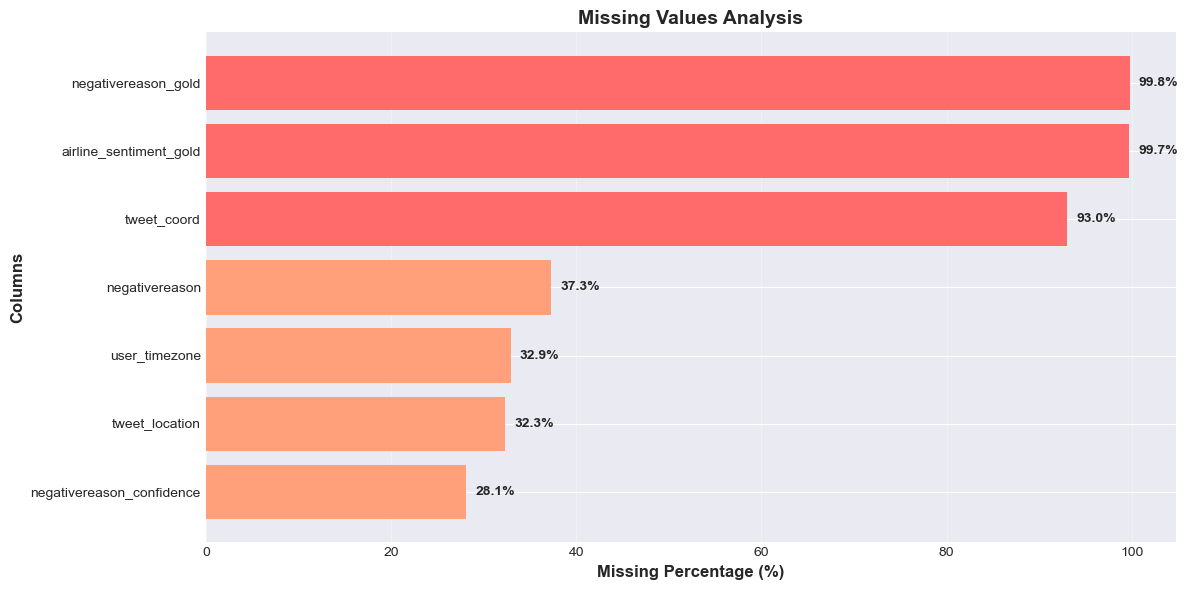

In [7]:
fig, ax = plt.subplots(figsize = (12, 6))
missing_data = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percent')

colors = ['#FF6B6B' if x > 50 else '#FFA07A' if x > 20 else '#FFD93D'
          for x in missing_data['Missing_Percent']]

ax.barh(missing_data['Column'], missing_data['Missing_Percent'], color = colors)
ax.set_xlabel('Missing Percentage (%)', fontsize = 12, fontweight = 'bold')
ax.set_ylabel('Columns', fontsize = 12, fontweight = 'bold')
ax.set_title('Missing Values Analysis', fontsize = 14, fontweight = 'bold')
ax.grid(axis = 'x', alpha = 0.3)

for i, (idx, row) in enumerate(missing_data.iterrows()):
    ax.text(row['Missing_Percent'] + 1, i, f'{row['Missing_Percent']:.1f}%',
            va = 'center', fontweight = 'bold')

plt.tight_layout()
plt.show()

In [8]:
sentiment_counts = df['airline_sentiment'].value_counts()
sentiment_pct = df['airline_sentiment'].value_counts(normalize = True) * 100

sentiment_summary = pd.DataFrame({
    'Sentiment': sentiment_counts.index,
    'Count': sentiment_counts.values,
    'Percentage': sentiment_pct.values.round(2)
})

print(sentiment_summary.to_string(index = False))

Sentiment  Count  Percentage
 negative   9178       62.69
  neutral   3099       21.17
 positive   2363       16.14


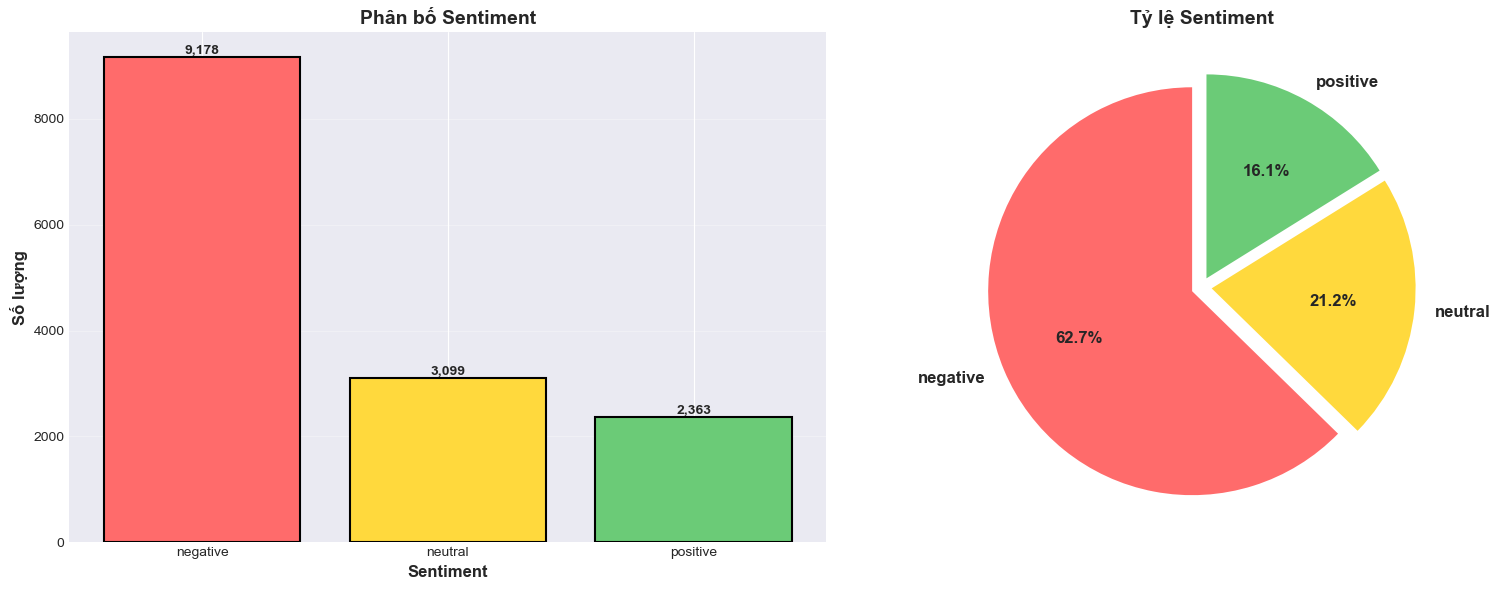


 INSIGHT: Dataset IMBALANCED - Negative chiếm 62.7%


In [9]:
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Bar chart
colors_bar = {'negative': '#FF6B6B', 'neutral': '#FFD93D', 'positive': '#6BCB77'}
sentiment_colors = [colors_bar[x] for x in sentiment_counts.index]

ax1 = axes[0]
bars = ax1.bar(sentiment_counts.index, sentiment_counts.values,
               color = sentiment_colors, edgecolor = 'black', linewidth = 1.5)
ax1.set_title('Phân bố Sentiment', fontsize = 14, fontweight = 'bold')
ax1.set_xlabel('Sentiment', fontsize = 12, fontweight = 'bold')
ax1.set_ylabel('Số lượng', fontsize = 12, fontweight = 'bold')
ax1.grid(axis = 'y', alpha = 0.3)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/ 2., height,
             f'{int(height):,}', ha = 'center', va = 'bottom', fontweight = 'bold')
    

# Pie chart
ax2 = axes[1]
colors_pie =[colors_bar[x] for x in sentiment_counts.index]
ax2.pie(sentiment_counts.values, labels = sentiment_counts.index,
        autopct = '%1.1f%%', colors = colors_pie, startangle = 90,
        textprops = {'fontsize': 12, 'fontweight': 'bold'},
        explode = (0.05, 0.05, 0.05))
ax2.set_title('Tỷ lệ Sentiment', fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()
print('\n INSIGHT: Dataset IMBALANCED - Negative chiếm 62.7%')

In [10]:
airline_counts = df['airline'].value_counts()
print('\n Số tweets theo airline:')
print(airline_counts)

airline_sentiment = pd.crosstab(df['airline'], df['airline_sentiment'],
                                normalize = 'index') * 100
print('\n Phân bố sentiment (%):')
print(airline_sentiment.round(2))


 Số tweets theo airline:
airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

 Phân bố sentiment (%):
airline_sentiment  negative  neutral  positive
airline                                       
American              71.04    16.78     12.18
Delta                 42.98    32.54     24.48
Southwest             49.01    27.44     23.55
US Airways            77.69    13.08      9.23
United                68.89    18.24     12.87
Virgin America        35.91    33.93     30.16


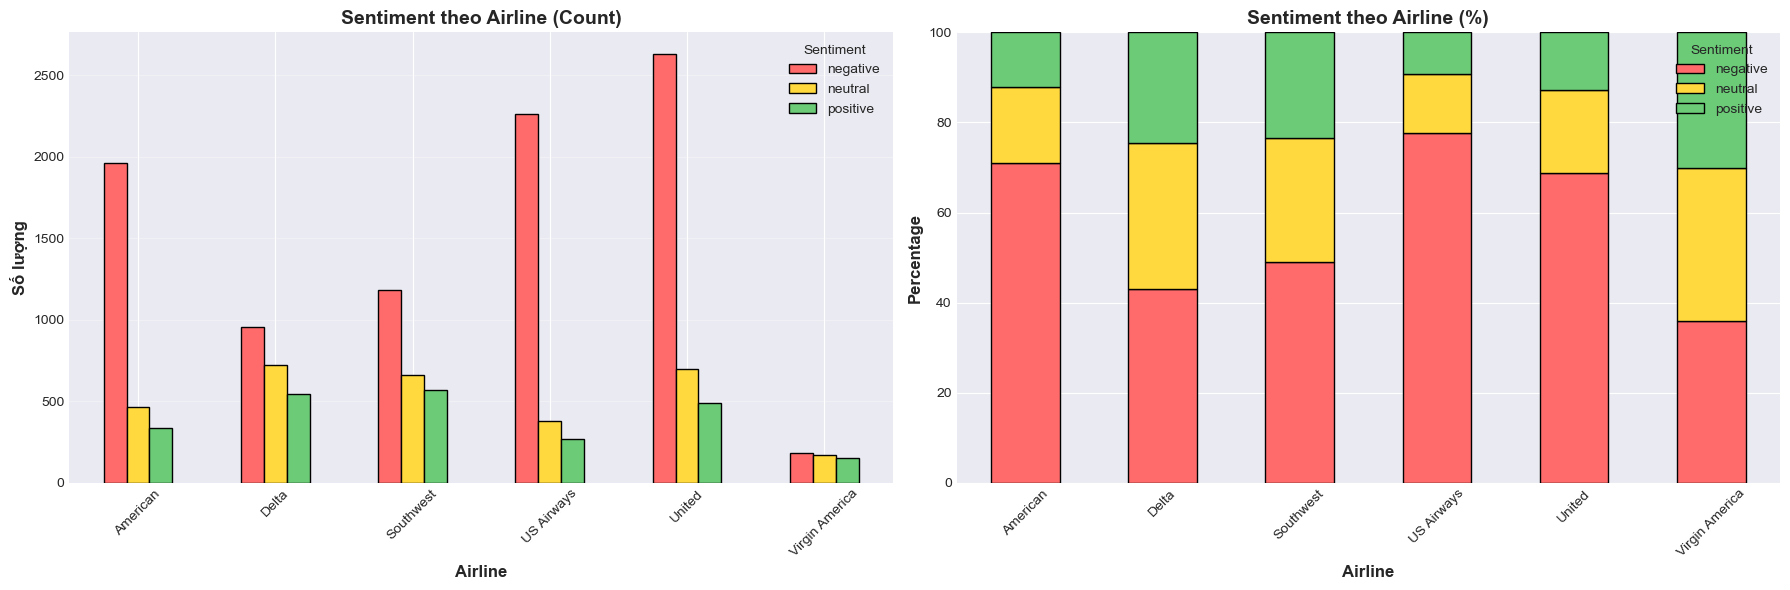

In [11]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

# Count chart
ax1 = axes[0]
airline_sentiment_count = pd.crosstab(df['airline'], df['airline_sentiment'])
airline_sentiment_count = airline_sentiment_count[['negative', 'neutral', 'positive']]
airline_sentiment_count.plot(kind = 'bar', stacked = False, ax = ax1,
                             color = ['#FF6B6B', '#FFD93D', '#6BCB77'],
                             edgecolor = 'black', linewidth = 1)
ax1.set_title('Sentiment theo Airline (Count)', fontsize = 14, fontweight = 'bold')
ax1.set_xlabel('Airline', fontsize = 12, fontweight = 'bold')
ax1.set_ylabel('Số lượng', fontsize = 12, fontweight = 'bold')
ax1.legend(title = 'Sentiment')
ax1.tick_params(axis = 'x', rotation = 45)
ax1.grid(axis = 'y', alpha = 0.3)

# Percentage chart
ax2 = axes[1]
airline_sentiment_pct = pd.crosstab(df['airline'], df['airline_sentiment'],
                                    normalize = 'index') * 100
airline_sentiment_pct = airline_sentiment_pct[['negative', 'neutral', 'positive']]

airline_sentiment_pct.plot(kind = 'bar', stacked = True, ax = ax2,
                           color = ['#FF6B6B', '#FFD93D', '#6BCB77'],
                            edgecolor = 'black', linewidth = 1 )
ax2.set_title('Sentiment theo Airline (%)', fontsize = 14, fontweight = 'bold')
ax2.set_xlabel('Airline', fontsize = 12, fontweight = 'bold')
ax2.set_ylabel('Percentage', fontsize = 12, fontweight = 'bold')
ax2.legend(title = 'Sentiment')
ax2.tick_params(axis = 'x', rotation = 45)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [12]:
negative_df = df[df['airline_sentiment'] == 'negative']
neg_reasons = negative_df['negativereason'].value_counts().head(10)

print("\nTop 10 lý do khách hàng phàn nàn:\n")
for i, (reason, count) in enumerate(neg_reasons.items(), 1):
    pct = (count / len(negative_df) * 100)
    print(f"{i:2d}. {reason:35s}: {count:4,} ({pct:5.2f}%)")


Top 10 lý do khách hàng phàn nàn:

 1. Customer Service Issue             : 2,910 (31.71%)
 2. Late Flight                        : 1,665 (18.14%)
 3. Can't Tell                         : 1,190 (12.97%)
 4. Cancelled Flight                   :  847 ( 9.23%)
 5. Lost Luggage                       :  724 ( 7.89%)
 6. Bad Flight                         :  580 ( 6.32%)
 7. Flight Booking Problems            :  529 ( 5.76%)
 8. Flight Attendant Complaints        :  481 ( 5.24%)
 9. longlines                          :  178 ( 1.94%)
10. Damaged Luggage                    :   74 ( 0.81%)


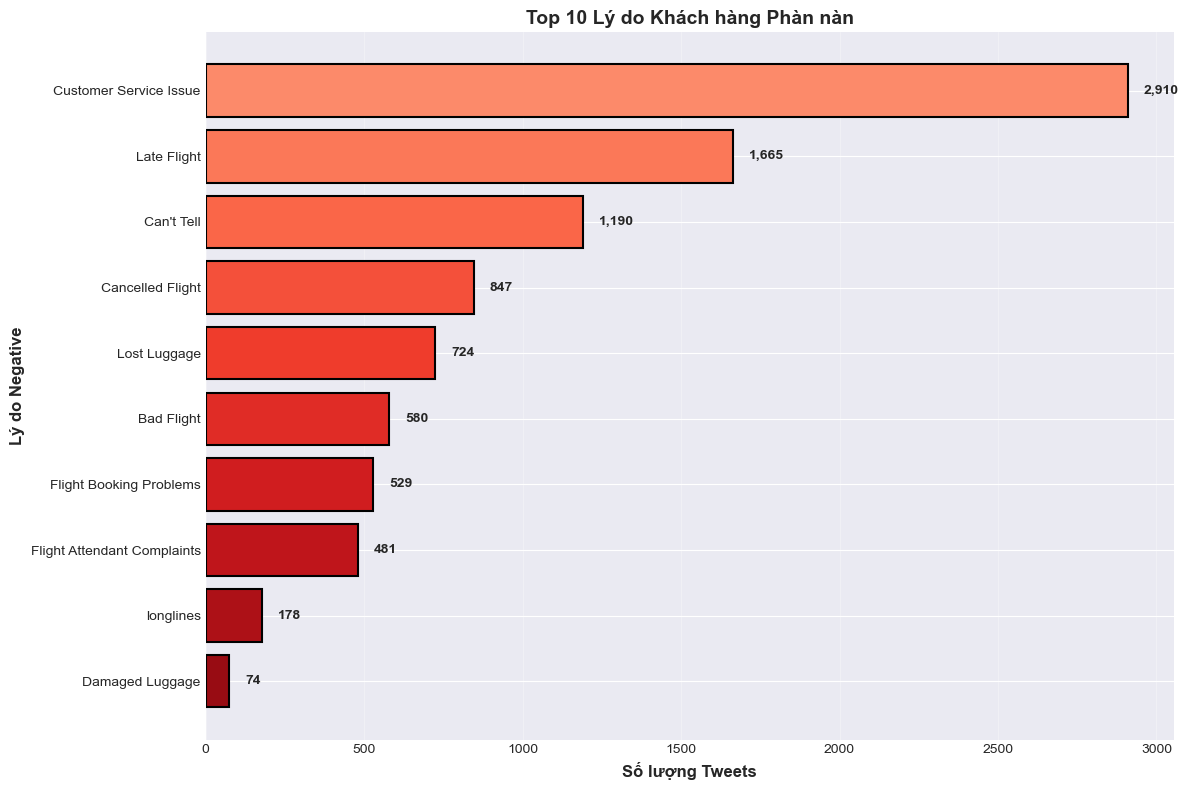

In [13]:
plt.figure(figsize=(12, 8))

colors_gradient = plt.cm.Reds(np.linspace(0.4, 0.9, len(neg_reasons)))

plt.barh(range(len(neg_reasons)), neg_reasons.values, 
         color=colors_gradient, edgecolor='black', linewidth=1.5)
plt.yticks(range(len(neg_reasons)), neg_reasons.index)
plt.xlabel('Số lượng Tweets', fontsize=12, fontweight='bold')
plt.ylabel('Lý do Negative', fontsize=12, fontweight='bold')
plt.title('Top 10 Lý do Khách hàng Phàn nàn', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

for i, value in enumerate(neg_reasons.values):
    plt.text(value + 50, i, f'{value:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
df_text = df.copy()
df_text['text_length'] = df_text['text'].str.len()

length_stats = df_text.groupby('airline_sentiment')['text_length'].describe()
print("\nThống kê độ dài tweet:\n")
print(length_stats.round(2))



Thống kê độ dài tweet:

                    count    mean    std   min   25%    50%    75%    max
airline_sentiment                                                        
negative           9178.0  113.95  30.72  12.0  96.0  126.0  138.0  176.0
neutral            3099.0   87.36  37.68  12.0  57.0   87.0  123.0  167.0
positive           2363.0   86.08  39.48  12.0  52.0   86.0  124.0  186.0


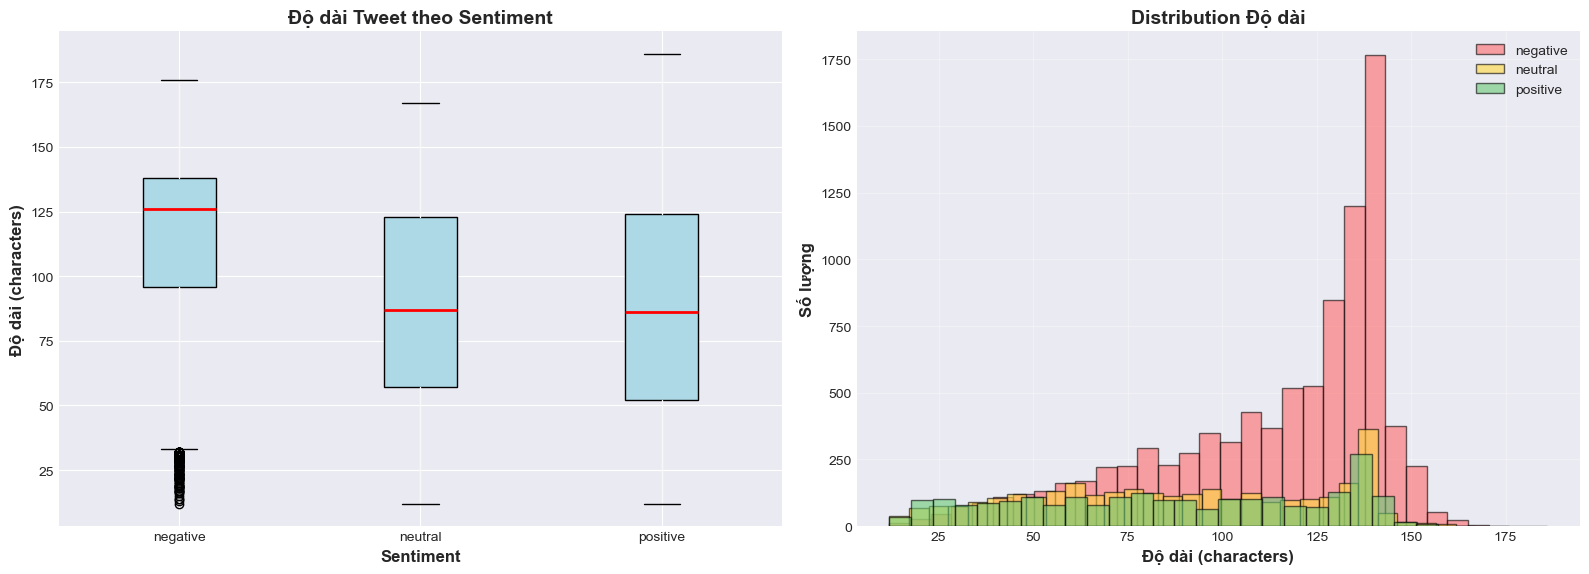

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
ax1 = axes[0]
df_text.boxplot(column='text_length', by='airline_sentiment', ax=ax1,
               patch_artist=True,
               boxprops=dict(facecolor='lightblue', edgecolor='black'),
               medianprops=dict(color='red', linewidth=2))
ax1.set_title('Độ dài Tweet theo Sentiment', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sentiment', fontsize=12, fontweight='bold')
ax1.set_ylabel('Độ dài (characters)', fontsize=12, fontweight='bold')
plt.suptitle('')

# Histogram
ax2 = axes[1]
for sentiment, color in zip(['negative', 'neutral', 'positive'], 
                           ['#FF6B6B', '#FFD93D', '#6BCB77']):
    data = df_text[df_text['airline_sentiment'] == sentiment]['text_length']
    ax2.hist(data, bins=30, alpha=0.6, label=sentiment, 
             color=color, edgecolor='black')

ax2.set_xlabel('Độ dài (characters)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Số lượng', fontsize=12, fontweight='bold')
ax2.set_title('Distribution Độ dài', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

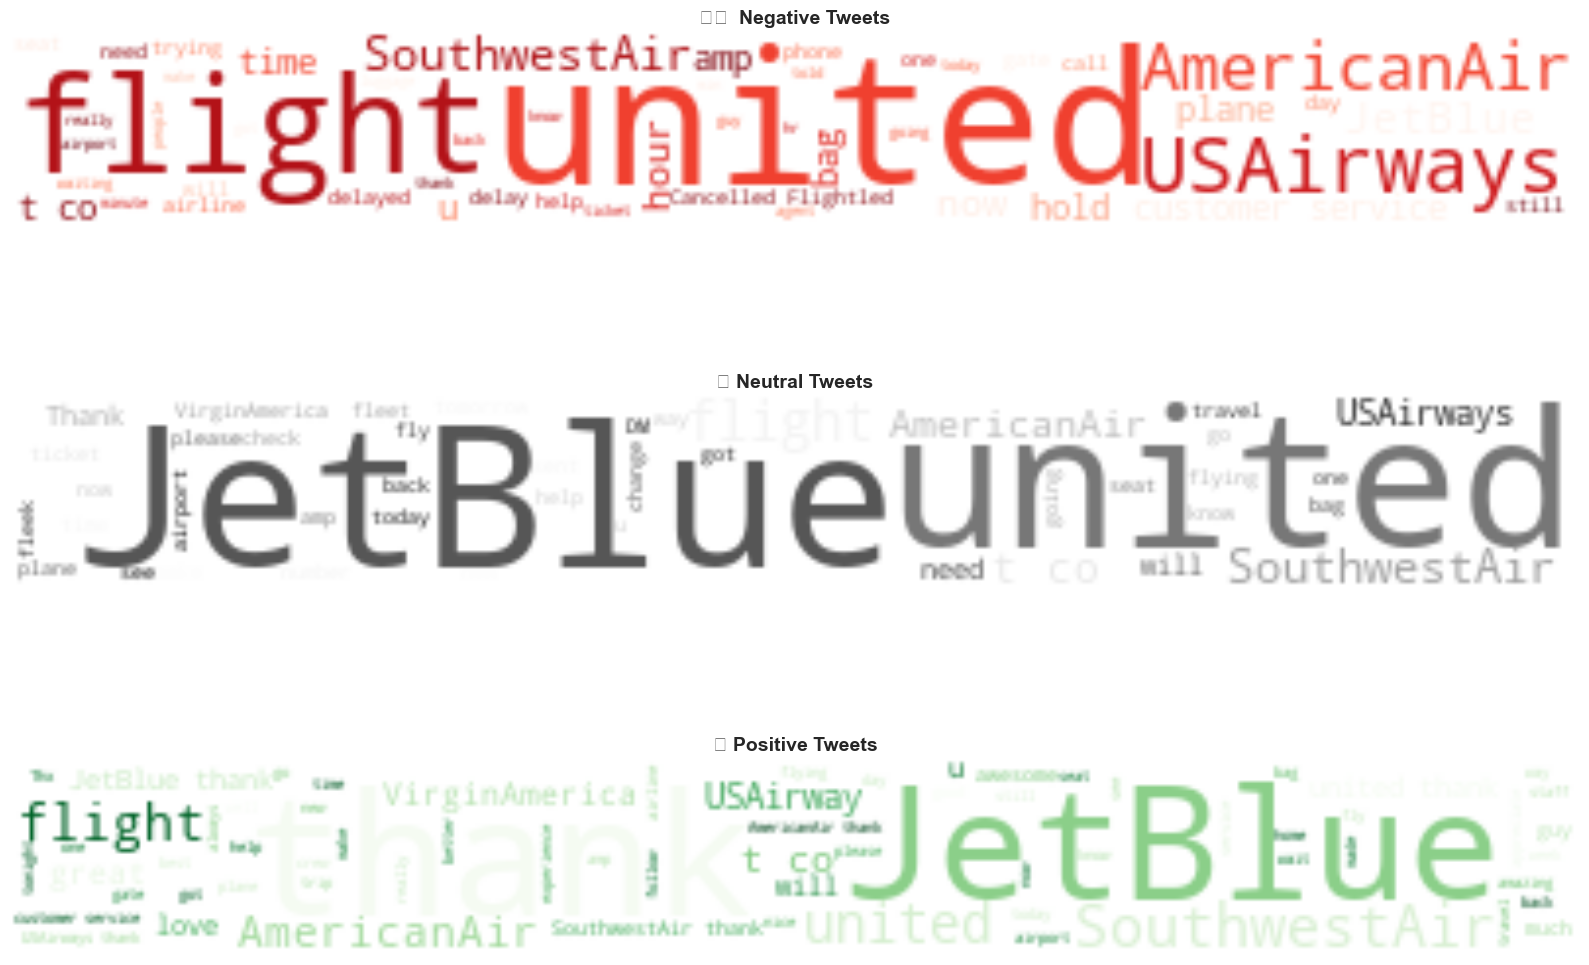

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

sentiments = ['negative', 'neutral', 'positive']
titles = ['☹️  Negative Tweets', '😐 Neutral Tweets', '😊 Positive Tweets']
colormaps = ['Reds', 'Greys', 'Greens']

for idx, (sentiment, title, cmap) in enumerate(zip(sentiments, titles, colormaps)):
    text = ' '.join(df_text[df_text['airline_sentiment'] == sentiment]['text'])
    
    wordcloud = WordCloud(
        width=400, height=50,
        background_color='white',
        colormap=cmap,
        max_words=100
    ).generate(text)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(title, fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()